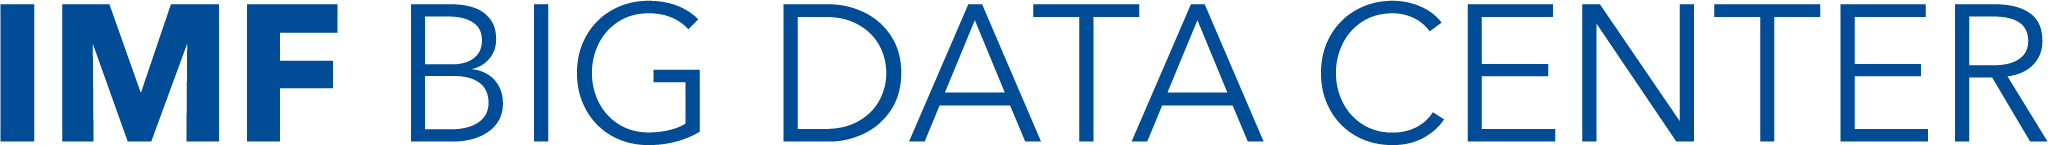

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlessandraSozzi/BDC_STI_26/blob/main/notebooks/BDC_Data_Extract_Satellite_Data.ipynb)

# Satellite data extraction

---

<br>**Contributors:** [Iyke Maduako](imaduako@imf.org), [Alberto Sanchez](asanchez3@imf.org), [Alessandra Sozzi](asozzi@imf.org)
<br> **Last update:** 2025-10-23 (Created: 2025-May)
<br> **Description:** This notebook extracts and saves data from Satellite Imagery and other sources
<br> **References:**

## Set-up

Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import libraries

In [ ]:
import ee
import geemap.foliumap as geemap
from geemap import cartoee
import pandas as pd
import numpy as np
import os
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

cartopy is not installed. Please see https://scitools.org.uk/cartopy/docs/latest/installing.html#installing for instructions on how to install cartopy.

The easiest way to install cartopy is using conda: conda install -c conda-forge cartopy


### Define scope

Country of interest

In [ ]:
#CountryName="Nigeria"
#CountryCode="NGA"

CountryName="Bulgaria"
CountryCode="BGR"


Time range

In [ ]:
startYear = 2010
endYear = 2025

### Authenticate to GEE

⏰**Enter your Google Cloud project name**

In [ ]:
ee.Authenticate()
my_project_name = 'ee-bigdatacenter-1' # USE YOUR OWN GOOGLE CLOUD PROJECT
ee.Initialize(project=my_project_name)

## Extract Satellite Data

⚠ ***NOTE: Data extraction can take a long time. We will skip this part during the workshop. Feel free to try on your own***

### **Extract NO2 data**

In [ ]:
# Initialize the Earth Engine object in case it was not executed
# ee.Initialize(project=my_project_name)

# Define the country name

# Select the Sentinel-5P NO2 dataset
dataset = ee.ImageCollection("COPERNICUS/S5P/NRTI/L3_NO2")

# Prepare Data For Download
country = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017").filter(ee.Filter.eq("country_na", CountryName))
geometry = country.geometry()

# Create an empty list to store feature collections for each month
tables = []

# Loop through each year and month
for year in range(startYear, endYear + 1):
    for month in range(1, 13):
        # Filter the dataset by the current year and month
        filteredDataset = dataset.filter(ee.Filter.calendarRange(year, year, "year")).filter(ee.Filter.calendarRange(month, month, "month"))

        # Reduce the dataset to calculate sum and mean tropospheric_NO2_column_number_density
        temporalReducer = ee.Reducer.sum()
        stats3 = filteredDataset.select("tropospheric_NO2_column_number_density").reduce(temporalReducer)
        stats = stats3.reduceRegion(reducer=ee.Reducer.sum().combine(ee.Reducer.mean(), "", True), geometry=geometry, scale=5000, maxPixels=1e9)

        # Extract sum_avg and mean_avg
        sum_avg = "NA"
        mean_avg = "NA"
        if stats.getInfo():
            sum_avg = stats.get("tropospheric_NO2_column_number_density_sum_sum")
            mean_avg = stats.get("tropospheric_NO2_column_number_density_sum_mean")
            #print(sum_avg)

        # Create a dictionary with properties for the year, month, sum, and mean
        feature_dict = {
            "Year": year,
            "Month": month,
            "Sum_tropospheric_NO2_column_number_density":sum_avg.getInfo() if sum_avg != "NA" else None,
            "Mean_tropospheric_NO2_column_number_density": mean_avg.getInfo() if mean_avg != "NA" else None
        }

        # Append the dictionary to the list of tables
        tables.append(feature_dict)

# Convert the list of dictionaries to a Pandas DataFrame
df = pd.DataFrame(tables)
df
# Save the data: Uncomment as needed
file_path1 = f"{CountryName}_NO2_{startYear}_{endYear}.csv"
df.to_csv(file_path1, index=False)


### **Extract NDVI data**

In [ ]:

# Initialize the Earth Engine object in case it was not executed
# ee.Initialize(project=my_project_name)

# Select the MOD13A3 dataset
dataset = ee.ImageCollection("MODIS/061/MOD13A3").filterBounds(country)

# Prepare Data For Download
country = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017").filter(ee.Filter.eq("country_na", CountryName))
geometry = country.geometry()

# Create an empty list to store feature collections for each month
tables = []

# Loop through each year and month
for year in range(startYear, endYear + 1):
    for month in range(1, 13):
        # Filter the dataset by the current year and month
        filteredDataset = dataset.filter(ee.Filter.calendarRange(year, year, "year")).filter(ee.Filter.calendarRange(month, month, "month"))

        # Reduce the dataset to calculate sum and mean NDVI
        temporalReducer = ee.Reducer.sum()
        stats3 = filteredDataset.select("NDVI").reduce(temporalReducer)
        stats = stats3.reduceRegion(reducer=ee.Reducer.sum().combine(ee.Reducer.mean(), "", True), geometry=geometry, scale=5000, maxPixels=1e9)

        # Extract sum_avg and mean_avg
        sum_avg = "NA"
        mean_avg = "NA"
        if stats.getInfo():
            sum_avg = stats.get("sum_ndvi_sum")
            mean_avg = stats.get("sum_mean_ndvi")

        # Create a dictionary with properties for the year, month, sum, and mean
        feature_dict = {
            "Year": year,
            "Month": month,
            "sum_ndvi": sum_avg.getInfo() if sum_avg != "NA" else None,
            "mean_ndvi": mean_avg.getInfo() if mean_avg != "NA" else None
        }

        # Append the dictionary to the list of tables
        tables.append(feature_dict)

# Convert the list of dictionaries to a Pandas DataFrame
df = pd.DataFrame(tables)
df


EEException: Dictionary.get: Dictionary does not contain key: 'sum_ndvi_sum'.

In [ ]:
# Save the data: Uncomment as needed
file_path3 = f"{CountryName}_NDVI_Stats_{startYear}_{endYear}.csv"
df.to_csv(file_path3, index=False)

### **Extract EVI data**

In [ ]:
# Initialize the Earth Engine object in case it was not executed
# ee.Initialize(project=my_project_name)

# Select the MOD13A3 dataset
dataset = ee.ImageCollection("MODIS/061/MOD13A3").filterBounds(country)

# Prepare Data For Download
country = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017").filter(ee.Filter.eq("country_na", CountryName))
geometry = country.geometry()

# Create an empty list to store feature collections for each month
tables = []

# Loop through each year and month
for year in range(startYear, endYear + 1):
    for month in range(1, 13):
        # Filter the dataset by the current year and month
        filteredDataset = dataset.filter(ee.Filter.calendarRange(year, year, "year")).filter(ee.Filter.calendarRange(month, month, "month"))

        # Reduce the dataset to calculate sum and mean EVI
        temporalReducer = ee.Reducer.sum()
        stats3 = filteredDataset.select("EVI").reduce(temporalReducer)
        stats = stats3.reduceRegion(reducer=ee.Reducer.sum().combine(ee.Reducer.mean(), "", True), geometry=geometry, scale=5000, maxPixels=1e9)

        # Extract sum_avg and mean_avg
        sum_avg = "NA"
        mean_avg = "NA"
        if stats.getInfo():
            sum_avg = stats.get("sum_evi_sum")
            mean_avg = stats.get("sum_mean_evi")

        # Create a dictionary with properties for the year, month, sum, and mean
        feature_dict = {
            "Year": year,
            "Month": month,
            "sum_evi": sum_avg.getInfo() if sum_avg != "NA" else None,
            "mean_evi": mean_avg.getInfo() if mean_avg != "NA" else None
        }

        # Append the dictionary to the list of tables
        tables.append(feature_dict)

# Convert the list of dictionaries to a Pandas DataFrame
df = pd.DataFrame(tables)
df


In [ ]:

# Save the data: Uncomment as needed
file_path4 = f"{CountryName}_EVI_Stats_{startYear}_{endYear}.csv"
df.to_csv(file_path4, index=False)

### **Extract Nighttime Lights data**

In [ ]:
# Initialize the Earth Engine object in case it was not executed
# ee.Initialize(project=my_project_name)

# Select the VIIRS NTL dataset
dataset = ee.ImageCollection("NASA/VIIRS/002/VNP46A2").filterBounds(country)

# Prepare Data For Download
country = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017").filter(ee.Filter.eq("country_na", CountryName))
geometry = country.geometry()

# Create an empty list to store feature collections for each month
tables = []

# Loop through each year and month
for year in range(startYear, endYear + 1):
    for month in range(1, 13):
        # Filter the dataset by the current year and month
        filteredDataset = dataset.filter(ee.Filter.calendarRange(year, year, "year")).filter(ee.Filter.calendarRange(month, month, "month"))

        # Reduce the dataset to calculate sum and mean Gap_Filled_DNB_BRDF_Corrected_NTL
        temporalReducer = ee.Reducer.sum()
        stats3 = filteredDataset.select("Gap_Filled_DNB_BRDF_Corrected_NTL").reduce(temporalReducer)
        stats = stats3.reduceRegion(reducer=ee.Reducer.sum().combine(ee.Reducer.mean(), "", True), geometry=geometry, scale=5000, maxPixels=1e9)

        # Extract sum_avg and mean_avg
        sum_avg = "NA"
        mean_avg = "NA"
        if stats.getInfo():
            sum_avg = stats.get("Gap_Filled_DNB_BRDF_Corrected_sum_ntl_sum")
            mean_avg = stats.get("Gap_Filled_DNB_BRDF_Corrected_sum_mean_ntl")

        # Create a dictionary with properties for the year, month, sum, and mean
        feature_dict = {
            "Year": year,
            "Month": month,
            "Sum_Gap_Filled_DNB_BRDF_Corrected_NTL": sum_avg.getInfo() if sum_avg != "NA" else None,
            "Mean_Gap_Filled_DNB_BRDF_Corrected_NTL": mean_avg.getInfo() if mean_avg != "NA" else None
        }

        # Append the dictionary to the list of tables
        tables.append(feature_dict)

# Convert the list of dictionaries to a Pandas DataFrame
df = pd.DataFrame(tables)
df



In [ ]:

# Save the data: Uncomment as needed
file_path1 = f"{CountryName}_NTL{startYear}_{endYear}.csv"
df.to_csv(file_path1, index=False)

### **Extract precipitation data**

In [ ]:
# Initialize the Earth Engine object in case it was not executed
# ee.Initialize(project=my_project_name)

# Select the MOD13A3 dataset
dataset = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").filterBounds(country)

# Prepare Data For Download
country = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017").filter(ee.Filter.eq("country_na", CountryName))
geometry = country.geometry()

# Create an empty list to store feature collections for each month
tables = []

# Loop through each year and month
for year in range(startYear, endYear + 1):
    for month in range(1, 13):
        # Filter the dataset by the current year and month
        filteredDataset = dataset.filter(ee.Filter.calendarRange(year, year, "year")).filter(ee.Filter.calendarRange(month, month, "month"))

        # Reduce the dataset to calculate sum and mean precipitation
        temporalReducer = ee.Reducer.sum()
        stats3 = filteredDataset.select("precipitation").reduce(temporalReducer)
        stats = stats3.reduceRegion(reducer=ee.Reducer.sum().combine(ee.Reducer.mean(), "", True), geometry=geometry, scale=5000, maxPixels=1e9)

        # Extract sum_avg and mean_avg
        sum_avg = "NA"
        mean_avg = "NA"
        if stats.getInfo():
            sum_avg = stats.get("precipitation_sum_sum")
            mean_avg = stats.get("precipitation_sum_mean")

        # Create a dictionary with properties for the year, month, sum, and mean
        feature_dict = {
            "Year": year,
            "Month": month,
            "Sum_precipitation": sum_avg.getInfo() if sum_avg != "NA" else None,
            "Mean_precipitation": mean_avg.getInfo() if mean_avg != "NA" else None
        }

        # Append the dictionary to the list of tables
        tables.append(feature_dict)

# Convert the list of dictionaries to a Pandas DataFrame
df = pd.DataFrame(tables)
df




In [ ]:
# Save the data: Uncomment as needed
file_path4 = f"{CountryName}_precipitation_Stats_{startYear}_{endYear}.csv"
df.to_csv(file_path4, index=False)

### **Extract agricultural indicators from FAO**

In [ ]:
import pandas as pd
import os

# Map of African country names to their respective codes
# country_codes = {
#     "Algeria": "DZA", "Angola": "AGO", "Benin": "BEN", "Botswana": "BWA", "Burkina Faso": "BFA",
#     "Burundi": "BDI", "Cabo Verde": "CPV", "Cameroon": "CMR", "Central African Republic": "CAF", "Chad": "TCD",
#     "Comoros": "COM", "Congo (Republic)": "COG", "Congo (Democratic Republic)": "COD", "Djibouti": "DJI",
#     "Egypt": "EGY", "Equatorial Guinea": "GNQ", "Eritrea": "ERI", "Eswatini": "SWZ", "Ethiopia": "ETH",
#     "Gabon": "GAB", "Gambia": "GMB", "Ghana": "GHA", "Guinea": "GIN", "Guinea-Bissau": "GNB",
#     "Ivory Coast": "CIV", "Kenya": "KEN", "Lesotho": "LSO", "Liberia": "LBR", "Libya": "LBY",
#     "Madagascar": "MDG", "Malawi": "MWI", "Mali": "MLI", "Mauritania": "MRT", "Mauritius": "MUS",
#     "Morocco": "MAR", "Mozambique": "MOZ", "Namibia": "NAM", "Niger": "NER", "Nigeria": "NGA",
#     "Rwanda": "RWA", "São Tomé and Príncipe": "STP", "Senegal": "SEN", "Seychelles": "SYC", "Sierra Leone": "SLE",
#     "Somalia": "SOM", "South Africa": "ZAF", "South Sudan": "SSD", "Sudan": "SDN", "Togo": "TGO",
#     "Tunisia": "TUN", "Uganda": "UGA", "Zambia": "ZMB", "Zimbabwe": "ZWE"
# }

country_codes = {
    "Turkey": "TUR",
    "Armenia": "ARM",
    "Kazakhstan": "KAZ",
    "Czech Republic": "CZE",
    "Lithuania": "LTU",
    "Romania": "ROU",
    "Albania": "ALB",
    "Austria": "AUT",
    "Moldova": "MDA",
    "Canada": "CAN",
    "Bulgaria": "BGR",
    "United Kingdom": "GBR",
    "Mongolia": "MNG",
    "Republic of Azerbaijan": "AZE",
    "Uzbekistan": "UZB",
    "Georgia": "GEO",
    "Slovenia": "SVN",
    "Slovak Republic": "SVK"
}

# Define a function to process country data
def process_country_data(country_name, country_code):
    print(f"Processing data for {country_name} ({country_code})")

    # Base URLs for the datasets
    base_urls = {
        "ASI_Dekad_Season1": f"https://www.fao.org/giews/earthobservation/asis/data/country/{country_code}/MAP_ASI/DATA/ASI_Dekad_Season1_data.csv",
        "NDVI_ADM1": f"https://www.fao.org/giews/earthobservation/asis/data/country/{country_code}/GRAPH_NDVI_AGRI/ndvi_adm1_data.csv",
        "VHI_ADM1_DEKAD": f"https://www.fao.org/giews/earthobservation/asis/data/country/{country_code}/MAP_NDVI_ANOMALY/DATA/vhi_adm1_dekad_data.csv",
    }

    dataframes = {}
    for key, url in base_urls.items():
        file_name = f"{key}_{country_code}.csv"
        print(f"Downloading {file_name} from {url}")
        os.system(f"wget -q -O {file_name} {url}")  # Download the file quietly

        if os.path.exists(file_name):
            with open(file_name, encoding='utf-8', errors='replace') as file:
                df = pd.read_csv(file)  # Read the file after opening it with error handling
            dataframes[key] = df
        else:
            print(f"Failed to download {file_name}. Skipping...")

    # Process and aggregate the data
    result_dfs = {}
    for key, df in dataframes.items():
        if "Date" not in df.columns or "Data" not in df.columns:
            print(f"Invalid format for {key}. Skipping...")
            continue

        if key == "NDVI_ADM1":
            variable_name = "NDVI_Anomaly"
        else:
            variable_name = key.split("_")[0]  # Default behavior

        df['Date'] = pd.to_datetime(df['Date'])
        df['YearMonth'] = df['Date'].dt.to_period('M')
        df_filtered = df[df['Date'].dt.year >= 2010]

        aggregated_df = df_filtered.groupby('YearMonth').agg(
            **{
                f"MonthlySum_{variable_name}": ('Data', 'sum'),
                f"MonthlyMean_{variable_name}": ('Data', 'mean'),
            }
        ).reset_index()

        aggregated_df['YearMonth'] = aggregated_df['YearMonth'].dt.to_timestamp()
        result_dfs[key] = aggregated_df

    # Merge all the result DataFrames
    merged_df = None
    for key, df in result_dfs.items():
        if merged_df is None:
            merged_df = df
        else:
            merged_df = pd.merge(merged_df, df, on='YearMonth', how='outer')

    return merged_df

# Reads data from selected country only
if CountryName in country_codes:
    country_code = country_codes[CountryName]
    country_df = process_country_data(CountryName, country_code)

    if country_df is not None:
        output_file = f"Merged_Data_{country_code}.csv"
        country_df.to_csv(output_file, index=False)
        print(f"Saved merged data for {CountryName} as {output_file}")
    else:
        print(f"No valid data for {CountryName}. Skipping...")
else:
    print(f"{CountryName} is not in the country list. Please check the name.")


Processing data for Nigeria (NGA)
Saved merged data for Nigeria as Merged_Data_NGA.csv


<h3> ⏰ Don't forget to adjust the path </h3>

In [ ]:
ROOT = "/content/drive/MyDrive/STI 2026/" #if using colab

workspace = "Day 2-3 - GDP Nowcasting/"
data_folder = "Data"
data_path = os.path.join(ROOT, workspace, data_folder)
data_path

'/content/drive/MyDrive/STI 2026/Day 2-3 - GDP Nowcasting/Data'

In [ ]:
CountryCode

'NGA'

In [ ]:
import pandas as pd

# Construct the file path using string formating
file_path1 = f"{data_path}/NTL/{CountryCode}.csv"
df_Ntl = pd.read_csv(file_path1)
df_Ntl

,date,year,month,mean_ntl,sum_ntl
0,2010-01-01,2010,1,NaN,NaN
1,2010-02-01,2010,2,NaN,NaN
2,2010-03-01,2010,3,NaN,NaN
3,2010-04-01,2010,4,NaN,NaN
4,2010-05-01,2010,5,NaN,NaN
...,...,...,...,...,...
187,2025-08-01,2025,8,NaN,NaN
188,2025-09-01,2025,9,NaN,NaN
189,2025-10-01,2025,10,NaN,NaN
190,2025-11-01,2025,11,NaN,NaN


Note regarding the **Day/Night Band (DNB)** data from the nighttime lights repository: provided by EOG group in Colorado School of Mines. We resorted to it when VIIRS Lunar Gap-Filled BRDF Nighttime Lights version 1 was discontinued, however, it also has a long lag (last update since March). There is no point in including it in our data unless we need to fill the gaps systematically.  VIIRS Lunar Gap-Filled BRDF Nighttime Lights version 2 is up-to-date.
Source: https://developers.google.com/earth-engine/datasets/catalog/NOAA_VIIRS_DNB_MONTHLY_V1_VCMCFG

https://www.earthdata.nasa.gov/topics/human-dimensions/nighttime-lights

In [ ]:
# # Construct the file path string using string formattin
# file_path_dnb = f"{data_path}/DNB/{CountryCode}.csv"
# df_Ntl_DNB = pd.read_csv(file_path_dnb)
# df_Ntl['mean_ntl_dnb']=df_Ntl_DNB['mean_ntl_dnb']
# df_Ntl['sum_ntl_dnb']=df_Ntl_DNB['sum_ntl_dnb']
# df_Ntl.head(50)

,date,year,month,mean_ntl,sum_ntl,mean_ntl_dnb,sum_ntl_dnb
0,2010-01-01,2010,1,NaN,NaN,NaN,NaN
1,2010-02-01,2010,2,NaN,NaN,NaN,NaN
2,2010-03-01,2010,3,NaN,NaN,NaN,NaN
3,2010-04-01,2010,4,NaN,NaN,NaN,NaN
4,2010-05-01,2010,5,NaN,NaN,NaN,NaN
5,2010-06-01,2010,6,NaN,NaN,NaN,NaN
6,2010-07-01,2010,7,NaN,NaN,NaN,NaN
7,2010-08-01,2010,8,NaN,NaN,NaN,NaN
8,2010-09-01,2010,9,NaN,NaN,NaN,NaN
9,2010-10-01,2010,10,NaN,NaN,NaN,NaN


In [ ]:
df_Ntl.head(5)

,date,year,month,mean_ntl,sum_ntl,mean_ntl_dnb,sum_ntl_dnb
0,2010-01-01,2010,1,NaN,NaN,NaN,NaN
1,2010-02-01,2010,2,NaN,NaN,NaN,NaN
2,2010-03-01,2010,3,NaN,NaN,NaN,NaN
3,2010-04-01,2010,4,NaN,NaN,NaN,NaN
4,2010-05-01,2010,5,NaN,NaN,NaN,NaN


In [ ]:
# Construct the file path string using string formattin
fao_file = f"{data_path}/FAO/{CountryCode}.csv"
df_Fao = pd.read_csv(fao_file)
df_Fao
df_Fao.ffill(inplace=True)
df_Fao

,date,sum_asi,mean_asi,sum_ndvi_anomaly,mean_ndvi_anomaly,sum_vhi,mean_vhi
0,2010-01-01,134.673,3.960971,43.814,0.394721,58.283,0.525072
1,2010-02-01,110.079,2.001436,42.199,0.380171,62.629,0.564225
2,2010-03-01,553.932,5.892894,41.070,0.370000,56.885,0.512477
3,2010-04-01,1036.633,10.366330,44.536,0.401225,56.827,0.511955
4,2010-05-01,760.379,6.975954,52.849,0.476117,57.481,0.517847
...,...,...,...,...,...,...,...
179,2024-12-01,443.372,11.084300,58.870,0.530360,63.900,0.575676
180,2025-01-01,360.827,10.612559,52.320,0.471351,66.021,0.594784
181,2025-02-01,840.751,16.485314,41.079,0.370081,64.620,0.582162
182,2025-03-01,1119.177,11.906138,40.934,0.368775,67.753,0.610387
